# Small Language Model

A GPT STyle small language model for Deeptrace Project.

In [1]:
#installing datasets and tiktoken
!pip install datasets tiktoken

In [2]:
#imports
from tiktoken import get_encoding
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device="cpu"

In [4]:
from datasets import load_dataset

ts = load_dataset("roneneldan/TinyStories")
ts

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

In [5]:
ts['train'][:10]['text']

['One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.',
 'Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.\n\nOne day, Beep was driving in the park when he saw a big tree. The tree had many leaves that we

In [6]:
sample_story=ts['train']['text'][0]

#-------------------IN own words write whatinput process andoutput

In [7]:
#encoding=get_encoding("cl100k_base")
encoding=get_encoding("r50k_base")
sample_tokens= encoding.encode(sample_story)
print(f"Token IDs : {list(sample_tokens)}")

Token IDs : [3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598, 287, 607, 2119, 13, 1375, 2993, 340, 373, 2408, 284, 711, 351, 340, 780, 340, 373, 7786, 13, 20037, 2227, 284, 2648, 262, 17598, 351, 607, 1995, 11, 523, 673, 714, 34249, 257, 4936, 319, 607, 10147, 13, 198, 198, 43, 813, 1816, 284, 607, 1995, 290, 531, 11, 366, 29252, 11, 314, 1043, 428, 17598, 13, 1680, 345, 2648, 340, 351, 502, 290, 34249, 616, 10147, 1701, 2332, 1995, 13541, 290, 531, 11, 366, 5297, 11, 20037, 11, 356, 460, 2648, 262, 17598, 290, 4259, 534, 10147, 526, 198, 198, 41631, 11, 484, 4888, 262, 17598, 290, 384, 19103, 262, 4936, 319, 20037, 338, 10147, 13, 632, 373, 407, 2408, 329, 606, 780, 484, 547, 7373, 290, 5742, 1123, 584, 13, 2293, 484, 5201, 11, 20037, 26280, 607, 1995, 329, 7373, 262, 17598, 290, 18682, 607, 10147, 13, 1119, 1111, 2936, 3772, 780, 484, 550, 4888, 290, 3111, 1978, 13]


In [8]:
sample_str = encoding.decode(sample_tokens)
sample_str

'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'

In [9]:
def tokeniser(sentences):
  ids= encoding.encode_ordinary_batch(sentence.lower() for sentence in sentences['text'])
  return {"ids":ids,"len": [len(id) for id in ids]}

In [10]:
tokenised_train= ts['train'].map(
    tokeniser,
    #input_columns='text',
    num_proc=4,
    batched=True
    #remove_columns='text'
)
tokenised_val= ts['validation'].map(
    tokeniser,
    #input_columns='text',
    batched=True,
    num_proc=4
)

Map (num_proc=4):   0%|          | 0/2119719 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/21990 [00:00<?, ? examples/s]

In [11]:
for split, data in zip(['train','val'],[tokenised_train,tokenised_val]):
  arrlen=np.sum(data['len'])
  arr=np.memmap(f"{split}.bin",dtype=np.uint16, mode="w+", shape=(arrlen,))
  nos_batches=1024
  idx=0
  for batch_index in tqdm(range(nos_batches)):
    bat = data.shard(num_shards=nos_batches,index=batch_index, contiguous=True).with_format("numpy")
    bat_arr = np.concatenate(bat['ids'])
    arr[idx:idx+len(bat_arr)]=bat_arr
    idx+=len(bat_arr)
  arr.flush()



  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

In [49]:
train_dat=np.memmap('train.bin', dtype=np.uint16, mode='r')

print(f"Total Token count :{len(train_dat)}")

Total Token count :478229515


In [50]:
first_few_tokens = list(train_dat[:100])
decoded_eg=encoding.decode(first_few_tokens)
decoded_eg

'one day, a little girl named lily found a needle in her room. she knew it was difficult to play with it because it was sharp. lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nlily went to her mom and said, "mom, i found this needle. can you share it with me and sew my shirt?" her mom smiled and said, "yes, lily, we can share the needle and fix'

In [51]:
block_siz=128
batch_size=32
def get_batch(split="train"):
  if split=="train":
    data = train_dat
  else:
    data= np.memmap('val.bin', dtype=np.uint16, mode='r')
  ix =torch.randint(len(data)-block_siz, (batch_size,))
  x=torch.stack([torch.from_numpy(((data[i:i+block_siz]).astype(np.int64)))for i in ix])
  y=torch.stack([torch.from_numpy(((data[i+1:i+1+block_siz]).astype(np.int64)))for i in ix])
  return x.to(device), y.to(device)

x_tr,y_tr=get_batch()
x_val,y_val=get_batch(split="val")
print(x_tr,y_tr)

tensor([[ 1064,   514,   617,  ...,   257,  9396,   290],
        [37687,   290,   285,  ...,  7812,   290,  4539],
        [ 4341,  2250,  1978,  ...,   991,  2861, 18088],
        ...,
        [ 7301,   262,  2156,  ...,  1312,  1101,  7819],
        [   13,   673,   857,  ...,   673,  1816,  2354],
        [ 2460,    13,   198,  ...,  2497,   465,  1545]], device='cuda:0') tensor([[  514,   617,  2057,  ...,  9396,   290,  2921],
        [  290,   285,   544,  ...,   290,  4539,  3049],
        [ 2250,  1978,  3375,  ...,  2861, 18088,   329],
        ...,
        [  262,  2156,    13,  ...,  1101,  7819,   287],
        [  673,   857,   407,  ...,  1816,  2354,   284],
        [   13,   198,   198,  ...,   465,  1545,    11]], device='cuda:0')


In [92]:
from dataclasses import dataclass
import torch.nn as nn
@dataclass
class GPTConfig:
  vocab_size:int
  block_size:int
  n_layer:int
  n_head:int
  n_embd:int
  dropout:float


class GPT(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.config=config
    self.wte=nn.Embedding(config.vocab_size, config.n_embd)
    self.wpe=nn.Embedding(config.block_size, config.n_embd)
    self.blocks = nn.ModuleList([
        nn.TransformerEncoderLayer(
            config.n_embd,config.n_head,4*config.n_embd,config.dropout,batch_first=True
        ) for i in range(config.n_layer)
    ])
    self.fln = nn.LayerNorm(config.n_embd)
    self.linout =nn.Linear(config.n_embd,config.vocab_size)

  def forward(self,idx,target=None):
    b,t=idx.size()
    tokenembd=self.wte(idx)
    pos=torch.arange(t,device=idx.device).unsqueeze(0)
    posemdb=self.wpe(pos)
    x=tokenembd+posemdb
    for block in self.blocks:
      x=block(x)
    x=self.fln(x)
    logits=self.linout(x)
    loss=None
    if target is not None:
      loss=F.cross_entropy(logits.view(-1,logits.size(-1)),
      target.view(-1)
      )

    return logits,loss

  @torch.no_grad()
  def generate(self,idx, max_tokens, temp=1.0,topk=None, topp=None):
    for i in range(max_tokens):
      nblksz=(-1)*self.config.block_size
      idx=idx[:,nblksz:]
      logits,_=self.forward(idx)
      logits=logits[:,-1,:]
      logits=logits/temp
      prbs=F.softmax(logits,dim=-1)
      gen=torch.multinomial(prbs,1,replacement=True)
      idx =torch.cat([idx, gen],dim=1)
    return idx



In [95]:
config=GPTConfig(
    vocab_size=50257,
    block_size=128,
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1
    )
model=GPT(config)
model=model.to(device)

In [54]:
lr=0.0001
max_iters=20000
warmup_stps=1000
min_lr=0.00005
eval_iters=500
batch_size=3
block_Size=128


optimiser=torch.optim.AdamW(
    params=model.parameters(),
    lr=lr,
  )
lrsch=torch.optim.lr_scheduler.CosineAnnealingLR(optimiser,max_iters)

In [60]:
inp=torch.randint(0,50257, (batch_size,block_Size))
inp.shape
optimiser.zero_grad()
logits,loss=model(inp)
logits.shape
#loss.backward()
tot_params=sum(p.numel() for p in model.parameters())
print(f"{tot_params/1000000:.2f}")

RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)

In [47]:
print(lr)
optimiser.step()
lrsch.step()
print(optimiser.param_groups[0]['lr'])


0.0001
9.999999938314972e-05


In [61]:
num_batches=20
def estimate_loss():
  model.eval()
  trloss,vloss=0,0
  for split in ['train','val']:
    avgloss=0
    for step in range(num_batches):
      with torch.no_grad():
        x,y=get_batch(split)
        logits,loss=model(x,y)
        avgloss+=loss
    avgloss/=(step+1)
    if split=='train':
      trloss=avgloss
    else:
      vloss=avgloss
  return trloss,vloss


In [65]:
#training loop
epochs=1
bestvloss = float("inf")
trloss_pts=[]
valloss_pts=[]
# steps=[10*i+i for i in range(20)]
trloss=0
#vallos=0
model.train()
for step in tqdm(range(1,max_iters+1)):
  x,y=get_batch()
  optimiser.zero_grad()
  logits,loss=model(x,y)
  #trloss+=loss
  if loss is not None:
    loss.backward()
  optimiser.step()
  lrsch.step()
  if step%200==0:
    trloss,vloss=estimate_loss()
    trloss_pts.append(trloss.item())
    valloss_pts.append(vloss.item())
    if vloss < bestvloss:
      bestvloss = vloss
      torch.save(model.state_dict(), "best_model.pt")
    print(f"Step {step} : Trloss : {trloss} | Valloss: {vloss}")
    model.train()


  0%|          | 0/20000 [00:00<?, ?it/s]

Step 200 : Trloss : 0.9124469757080078 | Valloss: 0.9414746165275574
Step 400 : Trloss : 0.7894814014434814 | Valloss: 0.8329319953918457
Step 600 : Trloss : 0.7609183192253113 | Valloss: 0.6681087017059326
Step 800 : Trloss : 0.6095777153968811 | Valloss: 0.6429978609085083
Step 1000 : Trloss : 0.5217422246932983 | Valloss: 0.5156877636909485
Step 1200 : Trloss : 0.49484068155288696 | Valloss: 0.4766886234283447
Step 1400 : Trloss : 0.42857858538627625 | Valloss: 0.455904483795166
Step 1600 : Trloss : 0.36200278997421265 | Valloss: 0.38689079880714417
Step 1800 : Trloss : 0.35175201296806335 | Valloss: 0.3398362100124359
Step 2000 : Trloss : 0.3505156338214874 | Valloss: 0.3774019181728363
Step 2200 : Trloss : 0.32120129466056824 | Valloss: 0.2994788587093353
Step 2400 : Trloss : 0.2927611470222473 | Valloss: 0.29935431480407715
Step 2600 : Trloss : 0.25231489539146423 | Valloss: 0.255852073431015
Step 2800 : Trloss : 0.26795583963394165 | Valloss: 0.23186293244361877
Step 3000 : Trlo

In [56]:
x, y = get_batch()
logits, loss = model(x, y)
print(loss)
print(x.min(), x.max())
print(config.vocab_size)

tensor(11.0224, device='cuda:0', grad_fn=<NllLossBackward0>)


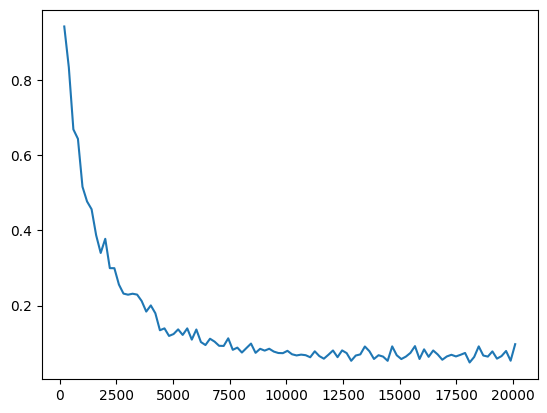

In [79]:
import matplotlib.pyplot as plt
steps=[200*i+i for i in range(1,101)]
# plt.plot(steps,[x.cpu().item() for x in trloss_pts])
plt.plot(steps,[x.cpu().item() for x in valloss_pts])
plt.show()


Fromthe losscruves,we can note that training loss and validation loss have decreased through the training process with minor fluctuations in their values.
Basedon this, the model does not show visible signs of overfitting.

In [96]:
#perplexity thing
import math
perplexity=math.exp(valloss_pts[-1].cpu().item())
print(f"Perplexity : {perplexity}")

Perplexity : 1.102401129594378


In [124]:
# text_input=input("Enter : ")
# text_input="Once upon a time"
# text_input="The little girl said"
text_input="Once a girl"
tokenids=encoding.encode_ordinary(text_input.lower())
token_ids=torch.tensor(tokenids)
token_ids = torch.tensor(tokenids).unsqueeze(0).to(device)

In [125]:
model1=GPT(config)
model1.load_state_dict(torch.load("best_model.pt", map_location=device))
model1.eval()
model1=model1.to(device)

In [126]:
generated =model1.generate(token_ids,128, temp=0.5)
# print(generated)
gen_text = encoding.decode(generated.squeeze(0).tolist())
print(gen_text)

 girl a a girl a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a


In [84]:
# torch.save(model.state_dict(), "best_model.pt")

In [127]:
#Issues